# INFO3020 Week 4 — Data Cleaning

**Dự án:** Điểm thi tốt nghiệp THPT 2023. **Hạn:** 23:59 ngày trước buổi Week 5.

Mục tiêu: phát hiện ngoại lệ → xác minh nguồn → chuẩn hóa văn bản → ghi nhật ký.
Notebook tái tạo toàn bộ kết quả trên CSV gốc; điểm và ô thiếu được giữ nguyên.
Các ví dụ Salary/Location/Experience trong đề chỉ minh họa phương pháp, không thuộc dữ liệu này.

Chọn Python của `.venv`. Chạy notebook từ thư mục gốc hoặc `notebooks`.
Bằng chứng web đã được ghi ngày kiểm tra trong `docs/week4_source_checks.json`; chạy lại không cần mạng.


In [1]:
from pathlib import Path
import sys
import pandas as pd
root = Path.cwd().resolve()
if not (root / 'src').is_dir():
    root = root.parent
if not (root / 'src/analyze_week4.py').is_file():
    raise RuntimeError('Mở notebook từ thư mục repo hoặc notebooks')
sys.path.insert(0, str(root))
from src.analyze_week4 import run, load_raw, detect_column, normalize_text, select_top5, SCORES, TEXT
# run() tái tạo bảng/hình; load_raw() đọc ID dạng chuỗi và giữ ô thiếu.
from src.analyze_week4 import VN
from src.week4_explanations import LABELS
metrics = run()
df = load_raw()
print('Số dòng:', f"{len(df):,}")
print('Cột:', list(df.columns))
print('SHA-256 nguồn:', metrics['source_sha256'])
print('Ngày kiểm tra web:', metrics['source_checked_at'])


Số dòng: 1,022,060
Cột: ['Student ID', 'Mathematics', 'Literature', 'Foreign language', 'Physics', 'Chemistry', 'Biology', 'History', 'Geography', 'Civic education', 'Foreign language code']
SHA-256 nguồn: cdf22a6b45f8e23b522beb1c521782e36486cac39d3fb64bca2a2395edec39b5
Ngày kiểm tra web: 2026-09-23


## EX4.1 — IQR và Z-score trên 9 cột điểm

Tính riêng từng môn trên **toàn bộ điểm quan sát**, không điền thiếu trước khi tính.

- IQR = Q3 − Q1, nội suy tuyến tính. Gắn cờ ngoài [Q1 − 1,5×IQR; Q3 + 1,5×IQR].
- Z = (x − μ)/σ, dùng `ddof=0`; gắn cờ khi |Z| > 3.
- Biên dùng bất đẳng thức nghiêm ngặt; giá trị nằm đúng ngưỡng không bị gắn cờ.
- Cột toàn thiếu hoặc σ=0 không gắn cờ Z; IQR=0 vẫn áp dụng khoảng suy biến.

Minh họa phép tính trực tiếp trên Toán; pipeline áp dụng cùng quy tắc cho cả 9 môn.


### Giải nghĩa và cách tính

**Ngoại lệ (outlier)** là giá trị nằm xa phần lớn điểm của cùng môn theo một quy tắc thống kê.
**Gắn cờ** là đánh dấu để điều tra, chưa phải kết luận dữ liệu sai.

| Ký hiệu / thuật ngữ | Ý nghĩa và cách tính |
| --- | --- |
| x | Một điểm thi cần kiểm tra, ví dụ điểm GDCD của một thí sinh. |
| n | Số điểm **không thiếu của môn đang xét**; mỗi môn có n khác nhau. |
| Q1, Q2, Q3 | Các mốc phân vị 25%, 50%, 75% của dãy điểm đã sắp xếp. Q2 là trung vị. |
| IQR = Q3 − Q1 | Độ rộng khoảng chứa 50% dữ liệu ở giữa; đo độ phân tán của phần trung tâm. |
| L = Q1 − 1,5 × IQR; U = Q3 + 1,5 × IQR | Ngưỡng dưới và trên của phương pháp IQR. Gắn cờ nếu x < L hoặc x > U. |
| μ = Σxᵢ / n | Trung bình: tổng các điểm quan sát chia cho số điểm quan sát. |
| σ = √[Σ(xᵢ − μ)² / n] | Độ lệch chuẩn tổng thể: bình phương độ lệch so với trung bình, lấy trung bình rồi căn bậc hai. `ddof=0` nghĩa là chia cho n. |
| Z = (x − μ) / σ | Khoảng cách từ x tới trung bình, tính bằng số lần độ lệch chuẩn. Z âm: thấp hơn trung bình; Z dương: cao hơn trung bình. |
| abs_z = trị tuyệt đối của Z | Bỏ dấu để so sánh độ lệch ở cả hai phía. Ngưỡng gắn cờ là abs_z > 3. |

**Nội suy tuyến tính khi tính phân vị:** sắp xếp n điểm thành x₀,…,xₙ₋₁. Với phân vị p,
tính h = (n−1)×p, k = phần nguyên của h, d = h−k. Nếu d=0 thì Q(p)=xₖ;
nếu d>0 thì Q(p)=xₖ+d×(xₖ₊₁−xₖ). Dùng p=0,25 để lấy Q1 và p=0,75 để lấy Q3.
Đây là quy ước `interpolation='linear'` của phép tính trong bài.

**Vì sao hai phương pháp khác nhau?** IQR dựa vào các phân vị ở giữa; Z-score dùng trung bình
và độ lệch chuẩn của toàn bộ điểm quan sát. Với phân phối lệch, hai cách có thể đặt ngưỡng khác nhau.
Ngưỡng 1,5 và 3 là quy tắc phát hiện trong bài, không phải xác suất một điểm bị nhập sai.
Không cần ép phân phối điểm thành hình chuông; histogram sẽ thể hiện phân phối thực tế.

Ô thiếu được bỏ khỏi phép tính thống kê, không thay bằng 0. Điểm đúng tại ngưỡng không bị gắn cờ.
Nếu σ=0 thì tất cả điểm quan sát bằng nhau và Z không xác định; nếu IQR=0 vẫn áp dụng khoảng
ngưỡng suy biến. Số hiển thị được làm tròn; chương trình so sánh bằng giá trị chưa làm tròn.


In [2]:
s = df['Mathematics']
# Tính hai phân vị trên điểm có dữ liệu (pandas bỏ NaN khi tính).
q1, q3 = s.quantile([0.25, 0.75], interpolation='linear')
iqr = q3 - q1
# True là một điểm có cờ; dùng < và > nên không gắn cờ điểm đúng tại biên.
iqr_flag = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
# ddof=0: độ lệch chuẩn tính với mẫu số n, tức số điểm quan sát.
z = (s - s.mean()) / s.std(ddof=0)
z_flag = z.abs() > 3
stats, checked_iqr, checked_z, _ = detect_column(s)
assert iqr_flag.equals(checked_iqr) and z_flag.equals(checked_z)
print('Toán: Q1, Q3, IQR =', q1, q3, iqr)
print('IQR:', int(iqr_flag.sum()), 'Z-score:', int(z_flag.sum()))
print(f'Ngưỡng IQR: dưới {q1 - 1.5 * iqr:.3f} hoặc trên {q3 + 1.5 * iqr:.3f}')
print(f'Tỷ lệ IQR = {int(iqr_flag.sum())} / {s.count()} × 100 = {100 * iqr_flag.sum() / s.count():.3f}%')


Toán: Q1, Q3, IQR = 5.2 7.6 2.3999999999999995
IQR: 1965 Z-score: 371
Ngưỡng IQR: dưới 1.600 hoặc trên 11.200
Tỷ lệ IQR = 1965 / 1003373 × 100 = 0.196%


### Cách đọc các bảng kết quả

| Cột trong CSV | Giải nghĩa / công thức |
| --- | --- |
| column | Môn học được phân tích. |
| n_observed / n_missing | Số điểm có dữ liệu / số điểm còn thiếu của môn đó. |
| q1, q3, iqr | Hai phân vị 25%, 75% và hiệu Q3 − Q1. |
| iqr_lower / iqr_upper | Hai ngưỡng L, U của IQR. |
| mean / std_population | Trung bình μ / độ lệch chuẩn σ với mẫu số n. |
| z_lower / z_upper | Ngưỡng điểm tương ứng μ−3σ / μ+3σ. |
| iqr_n / z_n | Số ô điểm được từng phương pháp gắn cờ. Hậu tố `_n` là số đếm. |
| both_n | Giao: bị **cả hai** phương pháp gắn cờ. |
| either_n | Hợp: bị **ít nhất một** phương pháp gắn cờ; bằng iqr_n + z_n − both_n. |
| iqr_only_n / z_only_n | Chỉ một phương pháp gắn cờ: iqr_n − both_n / z_n − both_n. |
| Các cột `_pct` | Tỷ lệ phần trăm = số cờ tương ứng / n_observed × 100. |
| source_row | Số dòng trong CSV gốc, tính từ 1 và tính cả dòng tiêu đề. |
| value / z_score / abs_z | Điểm gốc / Z có dấu / trị tuyệt đối của Z. |
| iqr_flag / z_flag | True = có cờ, False = không có cờ theo phương pháp tương ứng. |
| status | `ok`: tính bình thường; `all_missing`: toàn thiếu; `constant; z_undefined`: cột hằng; `zero_iqr; literal_fences`: IQR bằng 0. |

**Đơn vị đếm:** một thí sinh có thể bị gắn cờ ở nhiều môn. Vì vậy tổng số **ô điểm** được gắn cờ
có thể lớn hơn số **thí sinh**; số thí sinh được tính bằng số ID khác nhau trong bảng chi tiết.
Không cộng tỷ lệ của các môn vì chúng dùng mẫu số khác nhau.


In [3]:
tables = root / 'outputs/tables'
comparison = pd.read_csv(tables / 'week4_outlier_comparison.csv')
details = pd.read_csv(tables / 'week4_outlier_details.csv', dtype={'Student ID': 'string'})
# Chỉ dịch nhãn hiển thị; tên cột trong các CSV vẫn giữ nguyên để tra cứu.
visible = comparison.assign(column=comparison['column'].map(VN))
print(visible[['column', 'n_observed', 'iqr_n', 'z_n', 'both_n', 'either_n', 'iqr_only_n', 'z_only_n']].rename(columns=LABELS).to_string(index=False))
print('\nTỷ lệ %, mẫu số là số điểm quan sát của từng môn:')
print(visible[['column', 'iqr_pct', 'z_pct', 'either_pct']].rename(columns=LABELS).to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\nSố ô điểm bị gắn cờ:', metrics['flagged_cells'])
print('Số thí sinh khác nhau:', metrics['flagged_students'])
print('\nVí dụ truy vết:')
print(details.head(8).to_string(index=False))


Môn / cột  Có điểm  Cờ IQR  Cờ Z  Cả hai  Ít nhất một  Chỉ IQR  Chỉ Z
     Toán  1003373    1965   371     371         1965     1594      0
  Ngữ văn  1008239   11697  5598    5598        11697     6099      0
Ngoại ngữ   880997       0     0       0            0        0      0
   Vật lý   327189     481   481     481          481        0      0
  Hóa học   328118    1706   985     985         1706      721      0
 Sinh học   324625    1357  1222    1222         1357      135      0
  Lịch sử   683447     270   117     117          270      153      0
   Địa lý   682134    6627  2332    2332         6627     4295      0
     GDCD   565452   10754  5492    5492        10754     5262      0

Tỷ lệ %, mẫu số là số điểm quan sát của từng môn:
Môn / cột  IQR (%)  Z (%)  Ít nhất một (%)
     Toán   0.1958 0.0370           0.1958
  Ngữ văn   1.1601 0.5552           1.1601
Ngoại ngữ   0.0000 0.0000           0.0000
   Vật lý   0.1470 0.1470           0.1470
  Hóa học   0.5199 0.3002         

### Ví dụ thay số từ dữ liệu thật

**IQR môn Toán:** Q1 = 5,2, Q3 = 7,6.
IQR = 7,6 − 5,2 = **2,4**.
Ngưỡng dưới = 5,2 − 1,5 × 2,4 = **1,6**;
ngưỡng trên = 7,6 + 1,5 × 2,4 = **11,2**.
Vì miền điểm là 0–10, các cờ IQR Toán chỉ xuất hiện phía thấp.

**Z-score môn Toán:** μ ≈ 6,25056, σ ≈ 1,63334.
Ngưỡng dưới μ−3σ ≈ **1,35055**. Vì ngưỡng này thấp hơn ngưỡng IQR,
Z-score gắn cờ ít điểm Toán hơn trong dữ liệu này.

**Tỷ lệ IQR Toán** = 1,965 / 1,003,373 × 100
≈ **0,196%**. Mẫu số chỉ gồm người có điểm Toán, không phải toàn bộ 1.022.060 dòng.

**GDCD = 0 trong top 5:** Z = (0 − 8,28580) / 1,13764
≈ **−7,28335**.
Nghĩa là điểm này thấp hơn trung bình khoảng **7,28 độ lệch chuẩn**;
trị tuyệt đối vượt 3 nên có cờ Z-score. Kết quả này chưa chứng minh điểm bị nhập sai.


### Biểu đồ 1 — So sánh tỷ lệ ngoại lệ



**Cách đọc biểu đồ thanh:** trục ngang là tỷ lệ điểm bị gắn cờ (%); trục dọc là môn học.
Mỗi môn có hai thanh, một cho IQR và một cho Z-score. Thanh dài hơn nghĩa là phương pháp đánh dấu
tỷ lệ lớn hơn trong các điểm quan sát của môn đó. Nhãn cuối thanh ghi tỷ lệ và số ô điểm trong ngoặc.
Hai thanh có thể cùng chứa một điểm, nên không cộng chúng để tính hợp.

**Nhận xét:** GDCD có tỷ lệ cờ IQR cao nhất (khoảng 1,902%); Ngoại ngữ không có cờ theo hai ngưỡng này.
Ngữ văn có số cờ IQR lớn hơn GDCD nhưng tỷ lệ nhỏ hơn vì số người có điểm Ngữ văn lớn hơn.
Không có cờ không có nghĩa là mọi bản ghi đã được xác minh chính xác.

[Mở bản PNG để phóng to](../outputs/figures/week4_outlier_rates.png)

### Biểu đồ 2 — Phân bố điểm thực tế

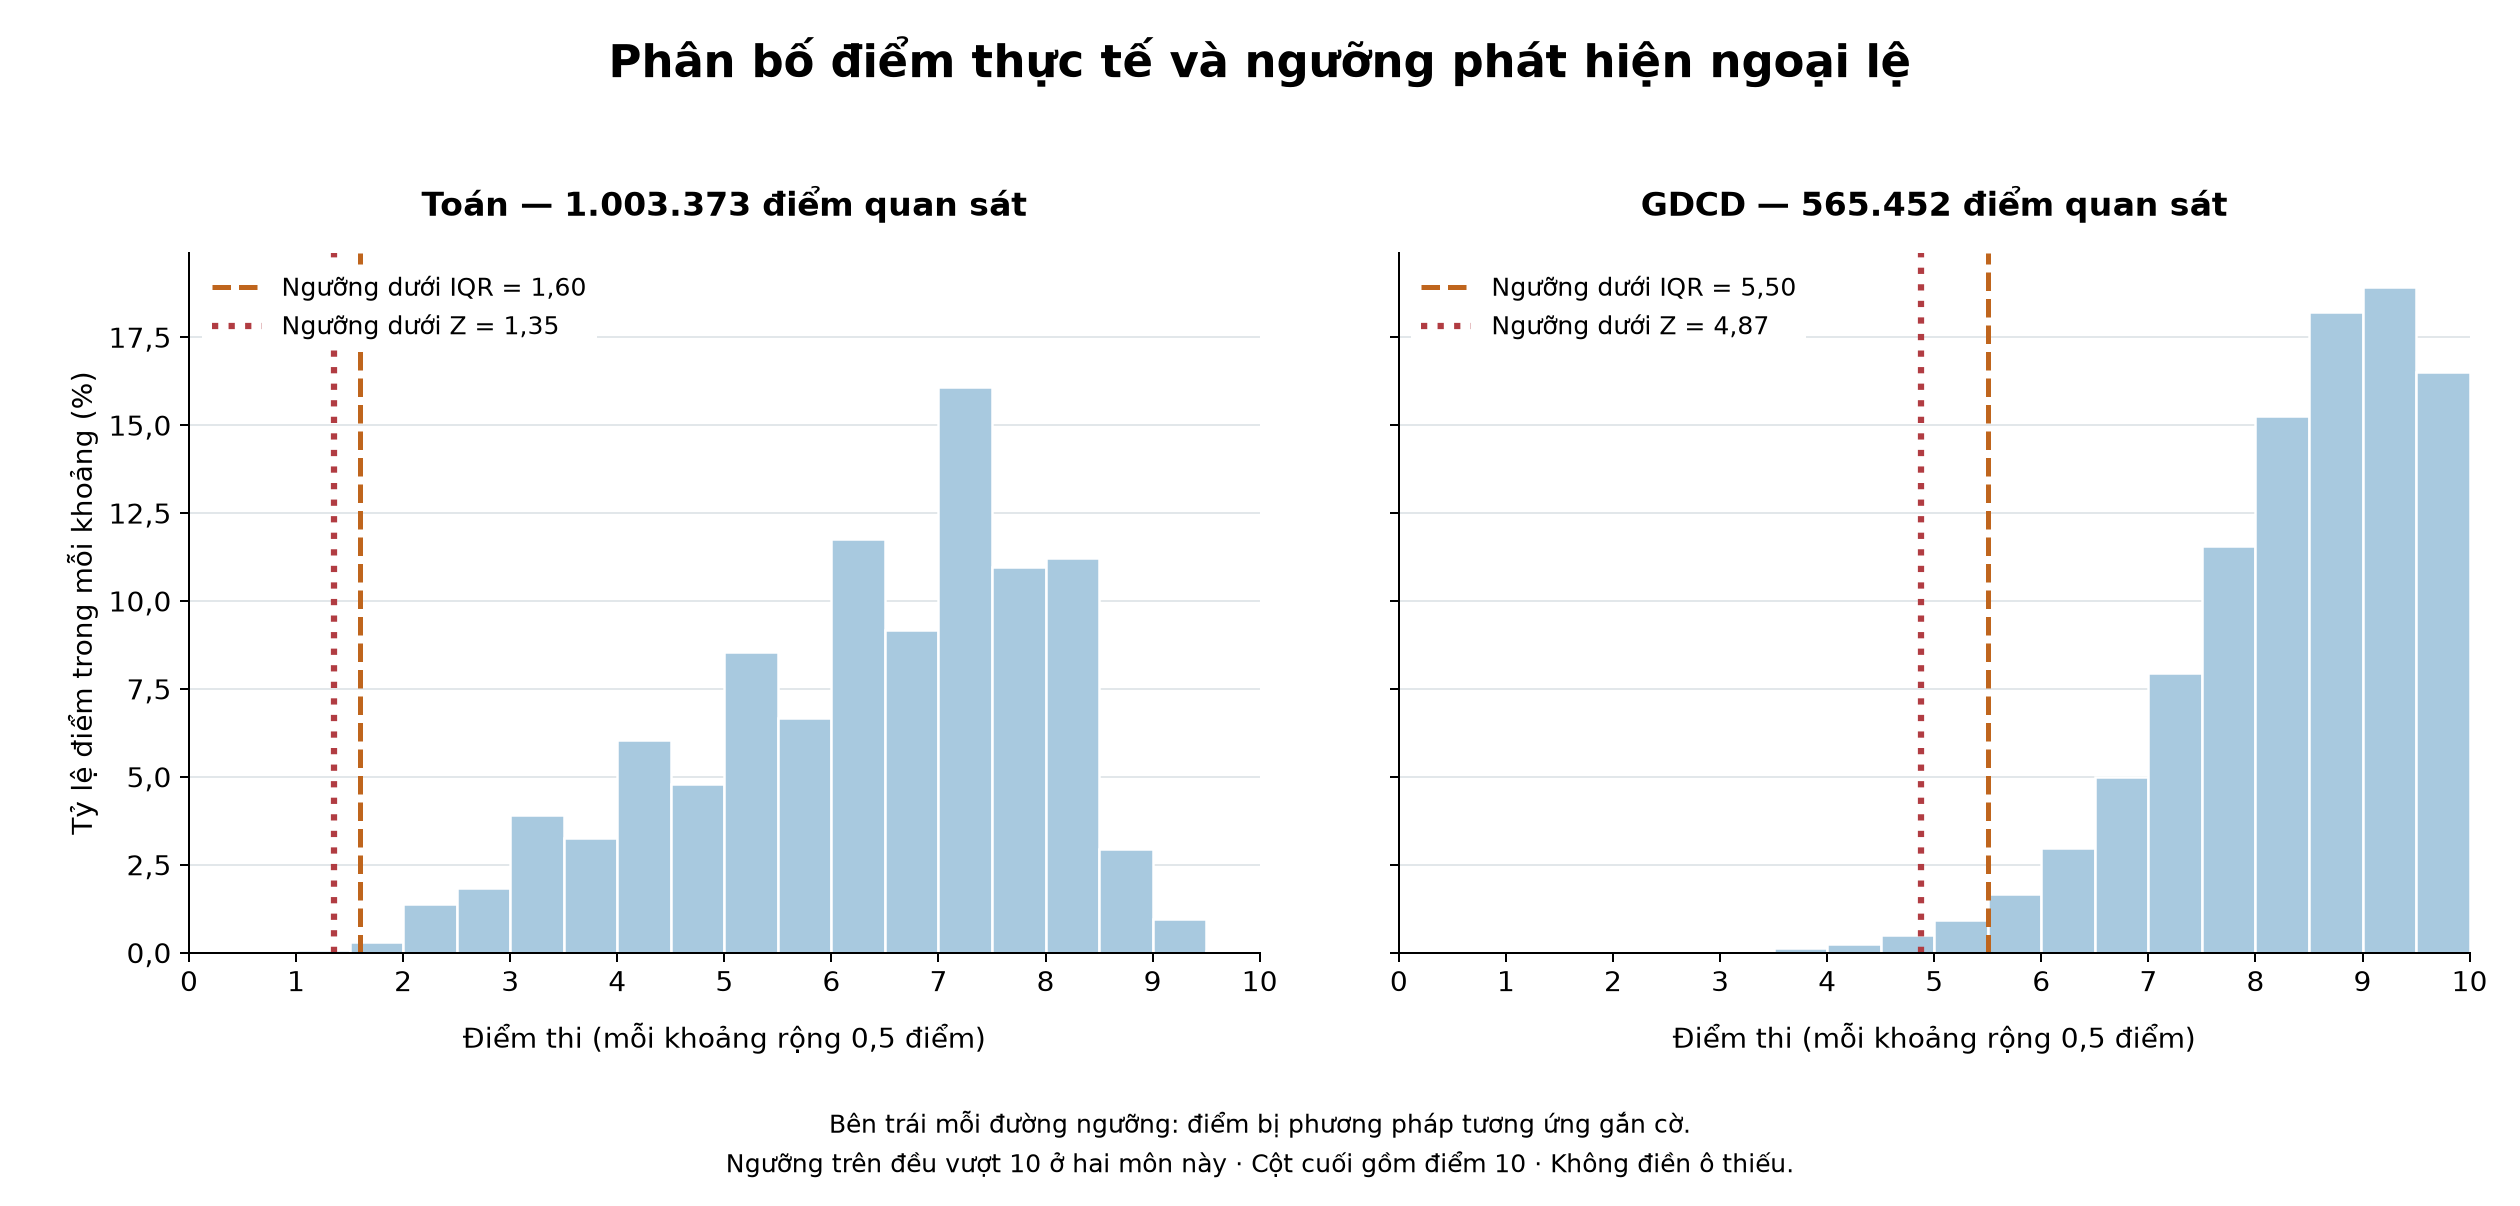

**Cách đọc histogram (biểu đồ tần suất):** trục ngang là điểm thi 0–10; trục dọc là
tỷ lệ điểm rơi vào từng khoảng rộng 0,5 điểm. Ví dụ cột [5; 5,5) đếm điểm từ 5 đến dưới 5,5;
cột cuối [9,5; 10] bao gồm điểm 10. Chiều cao cột = số điểm trong khoảng / số điểm quan sát × 100.
Các cột cộng lại bằng 100% trong từng môn; đây không phải trục mật độ xác suất.

Đường đứt màu cam là ngưỡng dưới IQR; đường chấm màu đỏ là ngưỡng dưới Z-score.
Điểm nằm **bên trái** đường tương ứng sẽ bị phương pháp đó gắn cờ.
Ngưỡng trên của hai phương pháp ở Toán và GDCD đều lớn hơn 10, nên nằm ngoài miền điểm được vẽ.
Không dùng chiều cao một cột sát ngưỡng để thay số đếm chính xác vì ngưỡng có thể cắt ngang khoảng.

**Nhận xét:** điểm GDCD tập trung nhiều ở vùng cao; do đó điểm 0 cách trung bình rất xa.
Điểm Toán phân bố rộng hơn và có ngưỡng thấp hơn. Histogram giải thích vì sao cùng một điểm thấp
có thể có độ lệch chuẩn hóa khác nhau giữa các môn, nhưng không xác minh được nguyên nhân của điểm đó.

[Mở bản PNG để phóng to](../outputs/figures/week4_score_histograms.png)

### Biểu đồ 3 — Boxplot ngang của 9 môn

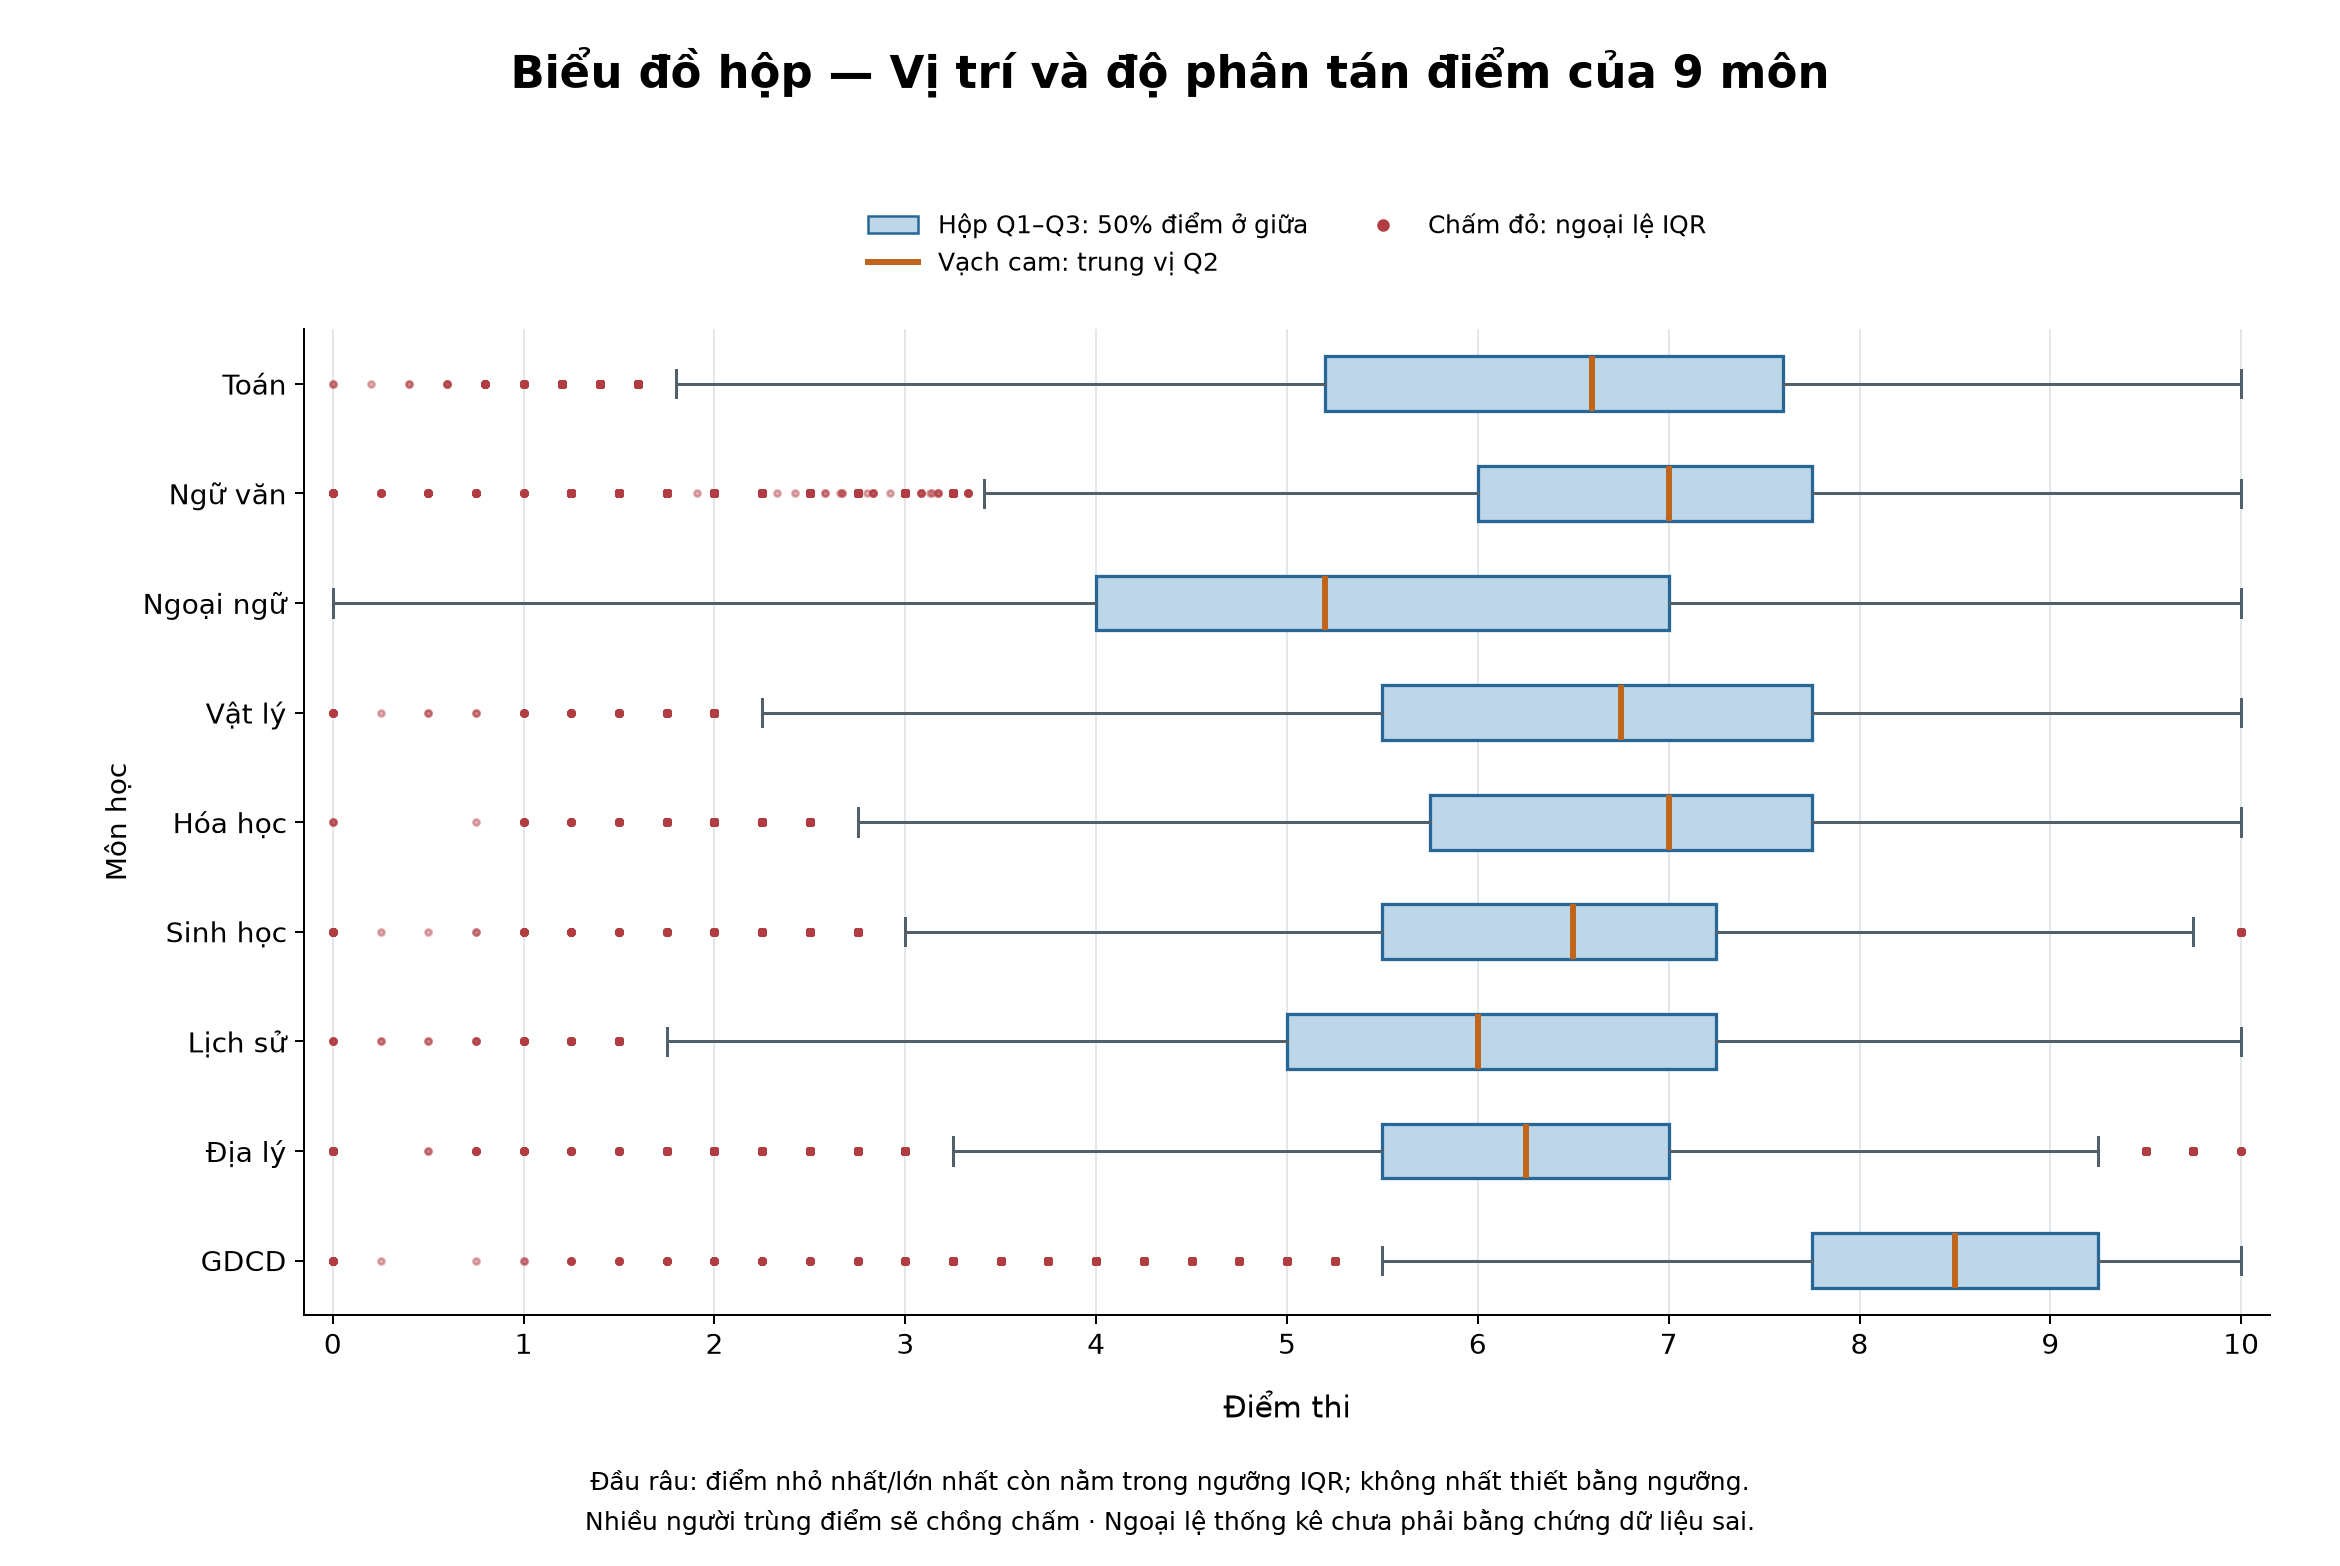

**Cách đọc boxplot (biểu đồ hộp):** trục ngang là điểm thi 0–10; mỗi hàng là một môn.
Mép trái hộp là Q1, vạch màu cam là trung vị Q2, mép phải hộp là Q3.
Hộp thể hiện khoảng 50% điểm ở giữa; hộp rộng hơn nghĩa là phần trung tâm phân tán hơn.

Hai **râu** kéo tới điểm quan sát nhỏ nhất/lớn nhất **vẫn nằm trong** [Q1−1,5×IQR; Q3+1,5×IQR].
Đầu râu không nhất thiết bằng chính ngưỡng tính toán. Các chấm đỏ ngoài râu là giá trị bị IQR gắn cờ.
Nhiều người có cùng điểm sẽ chồng lên một vị trí: không đếm số chấm nhìn thấy để suy ra số thí sinh.

**Nhận xét:** hộp GDCD nằm ở vùng điểm cao hơn hộp Toán; các điểm GDCD rất thấp tách xa khỏi hộp.
Đây là dấu hiệu cần kiểm tra nguồn, không phải kết luận dữ liệu sai.

[Mở bản PNG để phóng to](../outputs/figures/week4_boxplot.png)

## EX4.2 — Điều tra 5 ngoại lệ lớn nhất

“Lớn nhất” = |Z| lớn nhất trong **hợp** các cờ, xét cả phía thấp và cao.
Sắp xếp |Z| giảm dần, ID tăng dần, tên môn tăng dần; giữ ô đầu mỗi thí sinh rồi lấy 5.
Các trường hợp đồng hạng không được thay để lấy đủ nhiều môn.


### Ý nghĩa kết luận điều tra

| Thuật ngữ | Giải nghĩa |
| --- | --- |
| error | Có bằng chứng điểm ghi sai; chỉ sửa khi xác định được giá trị đúng từ nguồn đáng tin cậy. |
| real | Có đối chứng độc lập xác nhận điểm thực tế dù điểm bị gắn cờ thống kê. |
| unresolved | Chưa đủ bằng chứng để kết luận đúng hoặc sai; giữ giá trị và ghi giới hạn. |
| raw_token | Chuỗi chính xác trong ô CSV nguồn, ví dụ `0.0`; giúp phân biệt ô có số 0 và ô trống. |
| raw_record_matches | Đã đối chiếu bản ghi đọc lại từ CSV với dữ liệu phân tích. |
| processed_week3_matches | Đã đối chiếu bản ghi với bản Parquet Week 3. |
| within_0_10 | Điểm nằm trong miền hợp lệ; không đồng nghĩa đã xác minh chính xác. |
| source_sha256 | Dấu vân tay của tệp nguồn; dùng để nhận biết tệp có thay đổi hay không. |
| before / after | Giá trị trước/sau quyết định xử lý; bằng nhau khi giữ nguyên. |

Xếp hạng dùng trị tuyệt đối của Z nên điểm **thấp** cũng có thể đứng đầu.
Khi nhiều môn của một người có cờ, chỉ lấy môn có thứ hạng cao nhất của người đó trước khi lấy 5 ID.


In [4]:
selected = select_top5(details)
investigation = pd.read_csv(tables / 'week4_top5_investigation.csv', dtype={'Student ID': 'string', 'raw_token': 'string'})
assert selected['Student ID'].tolist() == investigation['Student ID'].tolist()
print(investigation[['rank', 'Student ID', 'source_row', 'column', 'value', 'abs_z', 'verdict', 'decision']].rename(columns=LABELS).to_string(index=False))
raw_records = pd.read_csv(tables / 'week4_top5_raw_records.csv', dtype='string', keep_default_na=False)
print('\nToàn bộ token của 5 dòng nguồn (ô trống vẫn để trống):')
print(raw_records.drop(columns='source_sha256').to_string(index=False))
for row in investigation.to_dict('records'):
    print('\nSBD', row['Student ID'], '—', row['reason'])
    print('Ngữ cảnh:', row['record_context'])
    print('Đối chiếu CSV / Parquet:', row['raw_record_matches'], row['processed_week3_matches'])
    print('Truy vấn:', row['search_query'])
    print('Kết quả:', row['search_result'])
    print('Nguồn:', row['source_urls'])
    print('Bằng chứng:', row['evidence_file'])


 Hạng Số báo danh  Dòng CSV       Môn / cột  Điểm  Độ lệch tuyệt đối Z   Kết luận Quyết định
    1    01053185     53186 Civic education   0.0             7.283349 unresolved Giữ nguyên
    2    01053192     53193 Civic education   0.0             7.283349 unresolved Giữ nguyên
    3    01053271     53272 Civic education   0.0             7.283349 unresolved Giữ nguyên
    4    02016503    118599 Civic education   0.0             7.283349 unresolved Giữ nguyên
    5    02019084    121180 Civic education   0.0             7.283349 unresolved Giữ nguyên

Toàn bộ token của 5 dòng nguồn (ô trống vẫn để trống):
source_row Student ID Mathematics Literature Foreign language Physics Chemistry Biology History Geography Civic education Foreign language code
     53186   01053185                    4.5                                                5.0       5.0             0.0                      
     53193   01053192         7.0       6.25                                               3.75   

### Kết luận điều tra

Cả 5 bản ghi có GDCD bằng 0; |Z| khoảng 7,28335. Toàn bộ 11 cột khớp CSV và bản Parquet Week 3.
Điểm trong [0,10] là hợp lệ về miền, **chưa chứng minh điểm thi chính xác**.

Trang Kaggle có mô tả dataset nhưng chưa xác minh được nguồn thu thập từng điểm.
Danh sách tra cứu năm 2023 dẫn đến trang Hà Nội hiện có tiêu đề 2026; công cụ web gặp lỗi
khi mở địa chỉ TP.HCM năm 2023. Không thu được bảng điểm độc lập cho 5 ID.
Kết luận **`unresolved` (chưa xác định), giữ nguyên**. Không tìm thấy qua tìm kiếm không chứng minh điểm sai.

Đọc [bằng chứng đầy đủ](../docs/week4_evidence.md) và [nhật ký kiểm tra nguồn](../docs/week4_source_checks.json)
để xem URL, ngày, trích đoạn và giới hạn; tệp điều tra CSV cũng lưu các quan sát theo từng ID.


## EX4.3 — Chuẩn hóa ít nhất hai cột văn bản

Dùng hai cột chuỗi có thật: **Student ID** và **Foreign language code**.
NFKC → bỏ khoảng trắng đầu/cuối → gộp khoảng trắng liên tiếp; mã ngoại ngữ chuyển chữ hoa.
ID được giữ chuỗi; không tự pad số 0 hoặc đoán mã. Kiểm tra `[0-9]{8}` và N1–N7.
Distinct không tính thiếu; thiếu có cột riêng. Không có biến thể tên tương đương để ánh xạ.


### Giải thích thao tác xử lý chuỗi

- **NFKC:** đưa các ký tự tương thích về cách biểu diễn thống nhất; ví dụ minh họa `Ｎ１` → `N1`.
- **strip:** bỏ khoảng trắng đầu/cuối; ví dụ minh họa `" N1 "` → `"N1"`.
- **Gộp khoảng trắng:** nhiều dấu cách/tab liên tiếp thành một dấu cách; không nối các phần ID để đoán mã.
- **uppercase:** chuyển mã ngoại ngữ thành chữ hoa; ví dụ minh họa `n1` → `N1`.
- **Kiểm tra `[0-9]{8}`:** ID phải có đúng 8 chữ số; giữ kiểu chuỗi để `01000001` không thành `1000001`.
- **N1–N7:** tập mã ngoại ngữ hợp lệ theo Data Card; giữ ô thiếu, không tự điền N1.

Các ví dụ trên chỉ giải thích quy tắc, **không phải lỗi được tìm thấy trong dataset**.

`distinct_before/after` là số giá trị khác nhau trước/sau, đếm bằng `nunique(dropna=True)`:
lặp nhiều lần vẫn chỉ tính một giá trị và không tính ô thiếu.
`missing_before/after` đếm ô thiếu riêng. `changed_rows` đếm số dòng có giá trị thực sự thay đổi;
hai ô cùng thiếu được coi là không đổi. `invalid_before/after` đếm giá trị không thiếu sai định dạng.
Thay cách viết không nhất thiết làm giảm distinct; distinct chỉ giảm khi các cách viết được gộp về cùng giá trị.


In [5]:
text_summary = pd.read_csv(tables / 'week4_text_standardization.csv')
print(text_summary.rename(columns=LABELS).to_string(index=False))
for col in TEXT:
    normalized = normalize_text(df[col], uppercase=(col == 'Foreign language code'))
    # Kiểm tra idempotent: làm sạch lại phải cho cùng kết quả, kể cả vị trí thiếu.
    pd.testing.assert_series_equal(normalized, normalize_text(normalized, uppercase=(col == 'Foreign language code')))
print('Chuẩn hóa lần hai không tạo thay đổi.')
print('0 dòng đổi là kết quả thật: không tạo dữ liệu lỗi giả để giảm distinct.')


            Môn / cột  Phân biệt trước  Phân biệt sau  Thiếu trước  Thiếu sau  Dòng đổi  Sai định dạng trước  Sai định dạng sau                                     Quy tắc
           Student ID          1022060        1022060            0          0         0                    0                  0            NFKC; strip; collapse whitespace
Foreign language code                7              7       141063     141063         0                    0                  0 NFKC; strip; collapse whitespace; uppercase
Chuẩn hóa lần hai không tạo thay đổi.
0 dòng đổi là kết quả thật: không tạo dữ liệu lỗi giả để giảm distinct.


## EX4.4 — Cleaning Log từ Week 3 đến Week 4

Giữ các trường ID, cột/bản ghi, vấn đề, bằng chứng, quyết định; bổ sung lý do, tuần, quy tắc,
`scope_rows` (số dòng thuộc phạm vi) và `changed_rows` (số dòng thực sự đổi trong dữ liệu chính).
Phạm vi có thể chồng lấp nên không cộng lại thành số người duy nhất.
Week 3 được tổng hợp lại từ báo cáo/code/metrics, ngày quyết định cũ để trống.
Điểm được điền thử Week 3 không đi vào dữ liệu chính; vẫn ghi 0 dòng dữ liệu chính bị thay đổi.


### Cách đọc Cleaning Log

| Trường | Ý nghĩa |
| --- | --- |
| ID / week | Mã quyết định / tuần có quyết định. |
| column_or_record / issue | Cột hoặc bản ghi được xét / vấn đề phát hiện. |
| evidence / reason | Nơi kiểm tra bằng chứng / lý do lựa chọn cách xử lý. |
| decision / rule | Hành động đã chọn / quy tắc áp dụng. |
| scope_rows | Số dòng thuộc phạm vi quyết định, kể cả khi cuối cùng giữ nguyên. |
| changed_rows | Số dòng có giá trị thay đổi trong dữ liệu chính bởi quyết định đó. |
| history_status / original_decision_date | Nguồn tổng hợp lịch sử / ngày quyết định gốc nếu biết. |

Ví dụ thực tế: chuẩn hóa Student ID xét **1.022.060 dòng** nhưng đổi **0 dòng**.
Điều tra một ID trong top 5 có phạm vi **1 dòng**, thay đổi **0 dòng** vì quyết định giữ nguyên.
Một bản ghi có thể nằm trong nhiều quyết định; không cộng `scope_rows` thành số người duy nhất.
**Round-trip** nghĩa là ghi CSV rồi đọc lại để so sánh; **idempotent** nghĩa là chuẩn hóa lần hai
không tạo thêm thay đổi. Hai phép kiểm giúp phát hiện việc mất số 0 đầu, đổi điểm hoặc đổi trạng thái thiếu.


In [6]:
log = pd.read_csv(tables / 'week4_cleaning_log.csv', keep_default_na=False)
print('Số quyết định:', len(log))
print(log[['ID', 'week', 'column_or_record', 'decision', 'scope_rows', 'changed_rows']].rename(columns=LABELS).to_string(index=False))
print('\nVí dụ đầy đủ một quyết định:')
print(log.loc[log['column_or_record'].eq('01053185: Civic education')].T.to_string(header=False))


Số quyết định: 35
   ID  Tuần                    Cột / bản ghi                             Quyết định  Dòng được xét  Dòng đổi
CL001     3                       Student ID                         Đọc dạng chuỗi        1022060         0
CL002     3                       9 cột điểm                                  Giữ 0            152         0
CL003     3                      Mathematics                               Giữ null          18687         0
CL004     3                       Literature                               Giữ null          13821         0
CL005     3                 Foreign language                               Giữ null         141063         0
CL006     3                          Physics                               Giữ null         694871         0
CL007     3                        Chemistry                               Giữ null         693942         0
CL008     3                          Biology                               Giữ null         697435         0
C

## Kiểm tra và kết quả bàn giao

Các phép kiểm dưới đây đối chiếu dữ liệu xuất với nguồn và bảng tổng hợp với từng cờ.
CSV được đọc với kiểu chuỗi cho hai cột mã; mở trực tiếp bằng Excel có thể tự chuyển ID thành số.


In [7]:
from src.analyze_week4 import sha256, RAW, CLEANED
assert sha256(RAW) == metrics['source_sha256']
cleaned = load_raw(CLEANED)
pd.testing.assert_frame_equal(df, cleaned, check_exact=True)
assert cleaned['Student ID'].iloc[0] == '01000001'
assert list(cleaned.columns) == metrics['columns']
for row in comparison.to_dict('records'):
    subset = details.loc[details['column'].eq(row['column'])]
    assert len(subset) == row['either_n']
    assert subset['iqr_flag'].sum() == row['iqr_n']
    assert subset['z_flag'].sum() == row['z_n']
assert investigation['Student ID'].nunique() == len(investigation) == 5
assert investigation['raw_record_matches'].all() and investigation['processed_week3_matches'].all()
assert all(metrics['validation'].values())
print('Đạt: nguồn bất biến; giữ số dòng, thứ tự, 11 cột, điểm, null và số 0 đầu.')
print('Đạt: số cờ khớp; top 5 duy nhất; bằng chứng đầy đủ theo khả năng truy cập.')
print('Kết luận: giữ điểm và null; 5 ngoại lệ chưa đủ bằng chứng xác minh đúng/sai.')


Đạt: nguồn bất biến; giữ số dòng, thứ tự, 11 cột, điểm, null và số 0 đầu.
Đạt: số cờ khớp; top 5 duy nhất; bằng chứng đầy đủ theo khả năng truy cập.
Kết luận: giữ điểm và null; 5 ngoại lệ chưa đủ bằng chứng xác minh đúng/sai.


## Tài liệu bài nộp

- [Báo cáo Week 4](../docs/week4_report+bao_cao.md)
- [CSV sau chuẩn hóa](../data/processed/week4_cleaned.csv)
- [So sánh ngoại lệ](../outputs/tables/week4_outlier_comparison.csv)
- [Điều tra top 5](../outputs/tables/week4_top5_investigation.csv)
- [Thống kê văn bản](../outputs/tables/week4_text_standardization.csv)
- [Cleaning Log](../outputs/tables/week4_cleaning_log.csv)
- [Metrics và các phép kiểm](../outputs/week4_metrics.json)

Đọc trước: Wes McKinney, *Python for Data Analysis*, mục 7.2 — Data Transformation.
